In [15]:
!pip install thrml jax jaxlib yfinance hmmlearn scikit-learn dieboldmariano -q

In [16]:

# 1.Importing libraries and modules

import numpy as np
import pandas as pd
import yfinance as yf
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as st
import warnings
warnings.filterwarnings('ignore')

from thrml import SpinNode, Block, SamplingSchedule, sample_states
from thrml.models import IsingEBM, IsingSamplingProgram, hinton_init
from hmmlearn.hmm import GaussianHMM
from matplotlib.ticker import FuncFormatter

#2. Asset universe , composed of S&P500 top 100 stocks
TICKERS = [
    'AAPL','MSFT','NVDA','AVGO','ORCL','CRM','AMD','QCOM','TXN','AMAT',
    'MU','KLAC','LRCX','ADI','MCHP','CDNS','SNPS','HPE','CSCO','IBM',
    'UNH','JNJ','LLY','ABBV','MRK','TMO','ABT','DHR','BMY','AMGN',
    'GILD','VRTX','CI','ELV',
    'JPM','BAC','WFC','GS','MS','BLK','AXP','SPGI','MCO','CME',
    'ICE','CB','PGR','TRV','AON','MMC',
    'AMZN','TSLA','HD','MCD','NKE','TJX','BKNG','LOW',
    'PG','KO','PEP','COST','WMT','PM','CL',
    'XOM','CVX','COP','EOG','SLB',
    'CAT','HON','UPS','RTX','LMT','GE','ETN',
    'GOOGL','META','NFLX','DIS','T','VZ',
    'NEE','DUK','SO',
    'PLD','AMT',
]

SECTOR_MAP = {
    'AAPL':'Tech','MSFT':'Tech','NVDA':'Tech','AVGO':'Tech','ORCL':'Tech',
    'CRM':'Tech','AMD':'Tech','QCOM':'Tech','TXN':'Tech','AMAT':'Tech',
    'MU':'Tech','KLAC':'Tech','LRCX':'Tech','ADI':'Tech','MCHP':'Tech',
    'CDNS':'Tech','SNPS':'Tech','HPE':'Tech','CSCO':'Tech','IBM':'Tech',
    'UNH':'Health','JNJ':'Health','LLY':'Health','ABBV':'Health','MRK':'Health',
    'TMO':'Health','ABT':'Health','DHR':'Health','BMY':'Health','AMGN':'Health',
    'GILD':'Health','VRTX':'Health','CI':'Health','ELV':'Health',
    'JPM':'Fin','BAC':'Fin','WFC':'Fin','GS':'Fin','MS':'Fin','BLK':'Fin',
    'AXP':'Fin','SPGI':'Fin','MCO':'Fin','CME':'Fin','ICE':'Fin','CB':'Fin',
    'PGR':'Fin','TRV':'Fin','AON':'Fin','MMC':'Fin',
    'AMZN':'ConDisc','TSLA':'ConDisc','HD':'ConDisc','MCD':'ConDisc','NKE':'ConDisc',
    'TJX':'ConDisc','BKNG':'ConDisc','LOW':'ConDisc',
    'PG':'ConStap','KO':'ConStap','PEP':'ConStap','COST':'ConStap','WMT':'ConStap',
    'PM':'ConStap','CL':'ConStap',
    'XOM':'Energy','CVX':'Energy','COP':'Energy','EOG':'Energy','SLB':'Energy',
    'CAT':'Indust','HON':'Indust','UPS':'Indust','RTX':'Indust',
    'LMT':'Indust','GE':'Indust','ETN':'Indust',
    'GOOGL':'Comm','META':'Comm','NFLX':'Comm','DIS':'Comm','T':'Comm','VZ':'Comm',
    'NEE':'Util','DUK':'Util','SO':'Util',
    'PLD':'RE','AMT':'RE',
}

TRAIN_START, TRAIN_END = '2010-01-01', '2022-12-31'
TEST_START,  TEST_END  = '2023-01-01', '2025-12-31'
K            = 30        # cardinality constraint
TC_BPS       = 10        # transaction cost in basis points
TC_RATE      = TC_BPS / 10_000
VIX_THRESHOLD = 20.0     # Mancilla et al. baseline threshold

# HMM coupling bounds matching our proposal formula γ_t = γ_low·P_low + γ_high·P_high
GAMMA_LOW  = 0.8   # calm regime coupling (penalise correlation strongly)
GAMMA_HIGH = 0.2   # stressed regime coupling (relax diversification pressure)

print('=' * 65)
print(' THRML Portfolio — Final Report')
print(' TC-DP + HMM Endogenous Regime vs VIX Exogenous Baseline')
print('=' * 65)

 THRML Portfolio — Final Report
 TC-DP + HMM Endogenous Regime vs VIX Exogenous Baseline


In [17]:
#2. Extracting data from yfinance library
raw = yf.download(
    TICKERS + ['^GSPC', '^VIX'],
    start=TRAIN_START, end=TEST_END,
    auto_adjust=True, progress=True
)['Close']
raw = raw.dropna(axis=1, thresh=int(0.95 * len(raw))).ffill().dropna() #Deletes any asset (column) that is missing more than 5% of its data.
#ffill- forward fills missing values

available = [t for t in TICKERS if t in raw.columns]
print(f'  {len(available)} tickers available')

all_returns = raw[available].pct_change().dropna() #drop na to remove any remaining rows that still contain NaN.
index_rets  = raw['^GSPC'].pct_change().dropna() #calculates the daily returns for the S&P 500 (^GSPC)
vix_series  = raw['^VIX'].dropna() #retrieves VIX series and drops NaN columns from VIX

train_rets = all_returns.loc[:TRAIN_END]
test_rets  = all_returns.loc[TEST_START:]
train_idx  = index_rets.loc[:TRAIN_END]
test_idx   = index_rets.loc[TEST_START:]
train_vix  = vix_series.loc[:TRAIN_END]
test_vix   = vix_series.loc[TEST_START:]

N = len(available)
print(f'  Train: {len(train_rets)} days | Test: {len(test_rets)} days')

[***************       31%                       ]  28 of 90 completed$MMC: possibly delisted; no timezone found
[*********************100%***********************]  90 of 90 completed

1 Failed download:
['MMC']: possibly delisted; no timezone found


  84 tickers available
  Train: 3149 days | Test: 751 days


In [18]:
#3. Regime detectors

#3a. VIX threshold (the VIX was used in the Mancilla et al. paper, and results from this replication serve as our baseline)
#This approach uses the VIX as a binary switch to indicate if the market is in a High Volatility or Low Volatility state.
vix_regimes = (test_vix > VIX_THRESHOLD).astype(int).reindex(test_idx.index).ffill().fillna(0).astype(int)

# 3b. HMM features: daily return, 5-day vol, 20-day vol
#Transforms the raw market returns into a feature matrix which can be interpreted by a hidden Markov Model
#In an HMM, the model cannot see the regime (like a low  or high volatility market) directly; 
#Rather the HMM looks at the three features (daily return, 5 day volatility and 20 day volatility) to infer which hidden state the market is most likely in.
def build_hmm_features(idx_rets):
    r   = idx_rets.values.reshape(-1, 1) #Daily return - captures the direction and magnitude of the price movements
    v5  = idx_rets.rolling(5).std().values.reshape(-1, 1) #5 day volatility captures the short-term realised risk
    v20 = idx_rets.rolling(20).std().values.reshape(-1, 1) #20 day volatility captures the medium-term realised risk 
    X   = np.hstack([r, v5, v20]) #for HMM the data must be in a specific format, so we convert the series into a 2D array where the rows are time steps and columns are features
    mask = ~np.isnan(X).any(axis=1)
    return X, mask

# 3c. Expanding window HMM re-estimation (to eliminate look-ahead bias) 
# At each quarterly rebalancing date we refit the HMM on ALL data up to thatdate (expanding window). 
# The stressed-state probability for the coming quarter is then derived from the last predicted state of the estimation window.
# This makes the regime signal fully endogenous and avoids using future data.

def fit_hmm_expanding(index_ret_series, as_of_date, min_obs=500, n_iter=2000):
    """
    Fit a 2-state GaussianHMM on all data up to as_of_date.
    Returns:
        stressed_prob : float — smoothed probability of being in stressed state
                        at as_of_date (used to set gamma)
        hmm           : fitted GaussianHMM object
        stressed_state: int — which component index is stressed
    """
    #An expanding window is used:
    #Instead of using a fixed number of days, 
    #it uses all data from the start of the dataset up to the as_of_date. 
    #As the backtest progresses, the knowledge of the model grows.
    
    window_rets = index_ret_series.loc[:as_of_date] 
    X, mask = build_hmm_features(window_rets)
    X_clean = X[mask]
    if len(X_clean) < min_obs: #ensures the model doesn't try to guess market regimes with too little data
        return 0.0, None, 1   # model defaults to calm if there is insufficient history
    #configuring the model: forcing the market into two specific buckets using 2 components (calm and stressed)
    hmm = GaussianHMM(n_components=2, covariance_type='full', #allows the model to look at the correlations between the three features
                      n_iter=n_iter, random_state=42)
    hmm.fit(X_clean)
    # Label: state with higher 20-day vol feature = stressed
    stressed_state = int(np.argmax(hmm.means_[:, 2])) #This accesses the mean value of the 3rd feature ( 20-day volatility) for both states.
    #Logic: Whichever state has the highest average 20-day volatility is the Stressed State.
    calm_state     = 1 - stressed_state
    # Smoothed posterior for the last observation
    posteriors = hmm.predict_proba(X_clean) #this calculates the smoothed probability for every day in the history.
    stressed_prob = float(posteriors[-1, stressed_state]) #stressed_prob: This represents the model's confidence. 
    #For example, a value of 0.85 tells us the model is 85% sure the market is currently in a stressed regime.
    return stressed_prob, hmm, stressed_state

#Full-Sample Fit:
# 3d. Initial full-sample HMM (for the regime detection graph) 
#Prepare the training data 
hmm_X_train, hmm_mask_train = build_hmm_features(train_idx) #The model uses the train_idx (the S&P 500 returns for the training period) to build the feature matrix.
X_clean = hmm_X_train[hmm_mask_train] #the model applies the mask to remove the NaN values from the start of the series.
# This ensures the HMM has a continuous and clean block of data to learn from.

#Fitting the global model
#fitted once on the entire training set to identify the two defining market regimes identified in the training years set
hmm_full = GaussianHMM(n_components=2, covariance_type='full',
                       n_iter=2000, random_state=42)
hmm_full.fit(X_clean)
#Identifying the stressed regime
stressed_state_full = int(np.argmax(hmm_full.means_[:, 2])) #we look at the mean of the 3rd feature (20-day volatility) for both states found in the training data.
#this is done to identify which state had the higher average volatility during the training period and labels it the Stressed period.
calm_state_full     = 1 - stressed_state_full

# Predict regimes on full test period using initial HMM (for plotting)
hmm_X_test, hmm_mask_test = build_hmm_features(test_idx)
test_X_clean = hmm_X_test[hmm_mask_test]
hmm_states_clean = hmm_full.predict(test_X_clean)
hmm_regimes = pd.Series(index=test_idx.index, dtype=int)
valid_idx   = test_idx.index[hmm_mask_test]
for i, date in enumerate(valid_idx):
    hmm_regimes[date] = 1 if hmm_states_clean[i] == stressed_state_full else 0
hmm_regimes = hmm_regimes.ffill().fillna(0).astype(int)

# Concordance statistic: HMM vs VIX regime overlap
common_idx  = hmm_regimes.index.intersection(vix_regimes.index)
agree       = (hmm_regimes.loc[common_idx] == vix_regimes.loc[common_idx]).mean()
n_hmm_stress = hmm_regimes.sum()
n_vix_stress = vix_regimes.loc[common_idx].sum()

print(f'  HMM stressed state={stressed_state_full}')
print(f'  HMM transition matrix:\n{np.round(hmm_full.transmat_, 3)}')
print(f'  HMM calm vol={hmm_full.means_[calm_state_full,2]*np.sqrt(252):.1%}, '
      f'stressed vol={hmm_full.means_[stressed_state_full,2]*np.sqrt(252):.1%}')
print(f'  Regime concordance (HMM vs VIX): {agree:.1%}')
print(f'  Stressed days — HMM: {n_hmm_stress} | VIX: {n_vix_stress}')

  HMM stressed state=1
  HMM transition matrix:
[[0.988 0.012]
 [0.043 0.957]]
  HMM calm vol=11.3%, stressed vol=27.5%
  Regime concordance (HMM vs VIX): 87.4%
  Stressed days — HMM: 76 | VIX: 129


In [19]:
#4 ISING / THRML application


def compute_ising_params(rets, tickers, coupling_gamma): 
    #This function transforms financial data into physics parameters: hi(biases) and Jij (coupling weights).
    """Compute normalised biases and coupling weights."""
    asset_r = rets[tickers] #fetches return data for the stocks we are interested in
    idx_r   = rets['^GSPC'] if '^GSPC' in rets.columns else train_idx.loc[rets.index[0]:rets.index[-1]] #Gets the benchmark returns (S&P 500) to compare against
    raw = []
    for t in tickers: #Loops through every stock to calculate its fitness.
        corr    = float(asset_r[t].corr(idx_r)) #Correlation of the stock with the market
        beta_v  = float(asset_r[t].cov(idx_r) / idx_r.var()) #The stock's Beta (tells us the sensitivity to market moves)
        tq      = corr * np.exp(-abs(beta_v - 1.0)) #Technical Quality. High correlation is preferred and stocks with Betas far away from 1.0 are penalised 
        mom     = float(asset_r[t].iloc[-252:-21].mean()) if len(asset_r) > 273 else 0.0 #Momentum, tells us the average returns over the last year (excluding the most recent month)
        liq     = float(asset_r[t].abs().mean())#Liquidity proxy which is based on average absolute returns
        raw.append(3.0 * tq + 1.0 * mom + 1.5 * liq) #A weighted sum of quality, momentum, and liquidity to create a raw score
    arr = np.array(raw, dtype=np.float32)
    hi  = ((arr - arr.mean()) / (arr.std() + 1e-8)).astype(np.float32) #Normalises the raw scores into Z-scores. 
    corr_mat = asset_r.corr().values.astype(np.float32) #Calculates how stocks move together
    edges, wts = [], []
    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            if abs(corr_mat[i, j]) > 0.5: #If two stocks are highly correlated, we create an edge (a connection) between them
                edges.append((i, j))
                wts.append(float(coupling_gamma * corr_mat[i, j] * 4.0)) #Sets the strength of the connection, gamma controls how much the system evaluates these relationships
    return jnp.array(hi), edges, jnp.array(wts, dtype=jnp.float32)

#The following function uses Gibbs Sampling to simulate the Ising model at different temperatures (β) to see which stocks are most robustly selected.
def thrml_selection_freq(hi, edges, weights, 
                         n_betas=10, n_warmup=200, n_samples=500, steps=30):
    """Multi-temperature THRML Gibbs sampling — returns per-asset selection frequencies."""
    N_assets = len(hi)
    all_freq = np.zeros(N_assets, dtype=np.float64)
    for beta_val in np.logspace(0.3, 1.8, n_betas).tolist(): #Loops through different temperatures. Low beta-high randomness; high beta- the system settles into its strongest state
        nodes    = [SpinNode() for _ in range(N_assets)] #Creates the particles (stocks) for the simulation
        edge_lst = [(nodes[i], nodes[j]) for i, j in edges]
        model    = IsingEBM(nodes, edge_lst, hi, weights, jnp.array(float(beta_val))) #Defines the Energy-Based Model using the biases (hi) and weights (Jij) calculated earlier.
        fb       = [Block(nodes[::2]), Block(nodes[1::2])] #Splits the nodes into Even and Odd blocks for faster parallel sampling
        program  = IsingSamplingProgram(model, fb, clamped_blocks=[]) #Defines how long to prepare the simulation and how many samples to take
        schedule = SamplingSchedule(n_warmup=n_warmup, n_samples=n_samples,
                                    steps_per_sample=steps)
        key      = jax.random.key(int(beta_val * 997) % (2**31))
        ki, ks   = jax.random.split(key, 2)
        init_state = hinton_init(ki, model, fb, ())
        #The core simulation is raw, it flips stock selections on and off to find the most stable configurations
        raw      = sample_states(ks, program, schedule, init_state, [],
                                 [Block(nodes[::2]), Block(nodes[1::2])])
        ea = np.array(raw[0]).reshape(n_samples, -1)
        oa = np.array(raw[1]).reshape(n_samples, -1)
        full = np.empty((n_samples, N_assets), dtype=np.float32) #Reconstructs the full portfolio from the even/odd blocks
        full[:, ::2]  = ea
        full[:, 1::2] = oa
        all_freq += full.mean(axis=0) #Calculates how often each stock was selected during the simulation
    return all_freq / n_betas

# The function below acts as a filter that takes the physics results and applies real-world constraints (like sector diversification).
def select_portfolio(tickers, freqs, K=30, max_sector_pct=0.25, min_sectors=6):
    df = pd.DataFrame({'Ticker': tickers, 'Freq': freqs,
                       'Sector': [SECTOR_MAP.get(t, 'Other') for t in tickers]})
    df = df.sort_values('Freq', ascending=False).reset_index(drop=True)
    selected, sc = [], {}
    max_ps = max(1, int(K * max_sector_pct))
    # Ensure min_sectors represented first
    for sector in df['Sector'].unique(): #Constraint 1: at least one stock from min_sectors different sectors is picked first 
        sub = df[df['Sector'] == sector]
        if len(selected) < K and len(sc) < min_sectors:
            pick = sub.iloc[0]['Ticker']
            selected.append(pick)
            sc[sector] = 1
    for _, row in df.iterrows():
        if len(selected) >= K:
            break
        t, s = row['Ticker'], row['Sector']
        if t not in selected and sc.get(s, 0) < max_ps:#Constraint 2: Adds the highest-frequency stocks but limits any single sector to max_sector_pct.
            selected.append(t)
            sc[s] = sc.get(s, 0) + 1
    for _, row in df.iterrows():#If the portfolio isn't full yet (less than K stocks), it fills the remaining spots with the next best stocks, ignoring sector limits
        if len(selected) >= K:
            break
        if row['Ticker'] not in selected:
            selected.append(row['Ticker'])
    return selected[:K] #Returns the final list of K stocks

In [20]:

#5 Transaction cost rebalancing
#This block implements a Transaction Cost-Aware Rebalancer.
#The rebalancer decides whether it is actually appropriate to change the portfolio, 
#or if the fees (transaction costs) will wipe out the benefits of moving to better stocks.

#Rather than just looking at one optimal portfolio, 
#in this block we generate several alternatives to see if a slightly different mix is cheaper to trade into
def dp_rebalance(current_holdings, candidate_freqs, tickers,
                 rets_window, idx_window, K=30, tc_rate=TC_RATE, n_candidates=5):
    """
    One-step lookahead DP:
        score(S) = tracking_quality(S) - tc_rate * annualised_turnover(S, current)
    Generates n_candidates sector-balanced portfolios from perturbed THRML
    frequencies and picks the one with the highest net score.
    """
    candidates = []
    for seed_offset in range(n_candidates):#Runs a loop to create several versions of the portfolio
        noise      = np.random.default_rng(seed_offset).normal(0, 0.02, len(tickers)) #Adds a tiny bit of random jitter to the stock rankings. 
        #This helps the algorithm look for near-optimal portfolios that might have more overlap with what we already have in our portfolio
        perturbed  = candidate_freqs + noise
        candidates.append(select_portfolio(tickers, perturbed, K=K)) #Uses the previously defined selection logic to create a sector-balanced portfolio for each noisy variation
    candidates.append(select_portfolio(tickers, candidate_freqs, K=K))
#The code iterates through every candidate portfolio and calculates a net Score based on two competing factors, tracking quality and turnover cost
    best_portfolio, best_score = None, -np.inf
    for cand in candidates:
        if not cand:
            continue
        tq_scores = []
        for t in cand:
            if t in rets_window.columns:
                c = float(rets_window[t].corr(idx_window)) #Measures how well each stock in the list correlates with the benchmark (S&P 500).
                tq_scores.append(c if not np.isnan(c) else 0.0)
        tq = np.mean(tq_scores) if tq_scores else 0.0
        if current_holdings is None:
            turnover = 1.0
        else:
            entering = len(set(cand) - set(current_holdings)) #Calculates how many stocks in the candidate list are not currently in the portfolio
            turnover = entering / K #The percentage of the portfolio being swapped
        net_score = tq - tc_rate * 250 * turnover #This is the penalty, scaled the trading cost by an annualisation factor 
        if net_score > best_score: #It picks the specific asset that gives the best balance of high quality and low cost
            best_score     = net_score
            best_portfolio = cand
    return best_portfolio if best_portfolio else candidates[-1]

In [21]:
#6 Training
#the first computation of the Ising model parameters using historical training data. 
#It determines how "sticky" the relationships between stocks should be based on market volatility
#VIX decides how much to weight the correlations between stocks.
train_vix_mean = float(train_vix.mean()) #Calculates the average market volatility during the training period
base_gamma     = float(np.clip(0.5 * np.exp(-0.5 * (train_vix_mean / 20.0 - 1.0)), 0.1, 0.8)) #This is a decay function for the coupling strength
#If the VIX is high (market panic), γ decreases. 
#This tells the model to rely less on historical correlations, which often break down during crashes.
train_rets_full              = train_rets.copy()
train_rets_full['^GSPC']     = train_idx #Appends the S&P 500 index returns to the dataset so the model can calculate Beta and "Technical Quality" relative to the market
hi_base, edges_base, wts_base = compute_ising_params(train_rets_full, available, base_gamma)
print(f'  Base γ={base_gamma:.3f}, {len(edges_base)} edges')

base_freqs = thrml_selection_freq(hi_base, edges_base, wts_base,
                                  n_betas=10, n_warmup=200, n_samples=500, steps=30) #runs the THRML Gibbs sampling simulation
print(f'  Mean selection frequency: {base_freqs.mean():.4f}')

  Base γ=0.519, 586 edges
  Mean selection frequency: 0.7262


In [22]:
#7. Quarterly backtest 
# Strategy A: VIX coupling, no TC-DP  (Mancilla et al. baseline)
# Strategy B: VIX coupling + TC-aware DP rebalancing
# Strategy C: HMM coupling (prob-weighted γ, expanding window) + TC-DP
#             γ_t = GAMMA_LOW·P_calm + GAMMA_HIGH·P_stressed
# Strategy D: Equal-weight index (reference)


test_dates = test_rets.index
quarters   = pd.date_range(start=test_dates[0], end=test_dates[-1], freq='QS')


def run_backtest(strategy_name, use_dp, regime_type='vix'):
    """
    regime_type : 'vix'  — use VIX threshold to set γ
                  'hmm'  — use expanding-window HMM probability-weighted γ
                  None   — use fixed base_gamma (no regime adaptation)
    """
    portfolio_returns = []
    current_holdings  = None
    rebalance_log     = []

    for q_idx, q_start in enumerate(quarters):
        q_end  = quarters[q_idx + 1] - pd.Timedelta(days=1) if q_idx + 1 < len(quarters) else test_dates[-1]
        q_mask = (test_dates >= q_start) & (test_dates <= q_end)
        q_rets = test_rets.loc[q_mask]
        q_idx_r = test_idx.loc[q_mask]
        if len(q_rets) == 0:
            continue

        # Determine regime-adaptive coupling 
        if regime_type == 'vix':
            q_vix_mean = float(test_vix.reindex(q_rets.index).ffill().fillna(20).mean())
            # Mancilla et al. VIX formula
            gamma_q    = float(np.clip(0.5 * np.exp(-0.5 * (q_vix_mean / 20.0 - 1.0)), 0.1, 0.8))
            regime_lbl = f"{'Stressed' if q_vix_mean > VIX_THRESHOLD else 'Calm'} (VIX={q_vix_mean:.1f})"

        elif regime_type == 'hmm':
            # Expanding-window HMM: fit on all data up to quarter start 
            # This eliminates look-ahead bias (professor's point 5)
            p_stressed, _, _ = fit_hmm_expanding(
                pd.concat([train_idx, test_idx.loc[:q_start]]),
                as_of_date=q_start
            )
            p_calm  = 1.0 - p_stressed
            # Proposal formula: γ_t = γ_low·P_calm + γ_high·P_stressed
            gamma_q = float(np.clip(GAMMA_LOW * p_calm + GAMMA_HIGH * p_stressed, 0.1, 0.8))
            regime_lbl = f"P_stress={p_stressed:.2f}, γ={gamma_q:.3f}"

        else:
            gamma_q    = base_gamma
            regime_lbl = f"Fixed γ={gamma_q:.3f}"

        # Lookback window for re-estimating Ising parameters
        lookback_start = q_start - pd.DateOffset(years=1)
        lb_rets = all_returns.loc[lookback_start:q_start]
        lb_idx  = index_rets.loc[lookback_start:q_start]

        # Re-run THRML with regime-adapted γ 
        lb_full = lb_rets.copy()
        lb_full['^GSPC'] = lb_idx
        try:
            hi_q, edges_q, wts_q = compute_ising_params(lb_full, available, gamma_q)
            freqs_q = thrml_selection_freq(hi_q, edges_q, wts_q,
                                          n_betas=6, n_warmup=100, n_samples=300, steps=30)
        except Exception as e:
            print(f'  Warning: THRML failed at {q_start.date()}: {e}, using base freqs')
            freqs_q = base_freqs.copy()

        # Portfolio selection
        if use_dp:
            new_holdings = dp_rebalance(
                current_holdings, freqs_q, available,
                q_rets, q_idx_r, K=K, tc_rate=TC_RATE
            )
        else:
            new_holdings = select_portfolio(available, freqs_q, K=K)

        # compute turnover BEFORE updating current_holdings
        if current_holdings is None:
            turnover = K          # first period: all K stocks are new
            tc_drag  = TC_RATE    # full initial cost
        else:
            entering = len(set(new_holdings) - set(current_holdings))
            turnover = entering
            tc_drag  = TC_RATE * entering / K

        # Next update current_holdings 
        current_holdings = new_holdings

        # Compute equal-weight portfolio returns
        held_in_test = [t for t in new_holdings if t in q_rets.columns]
        port_q       = q_rets[held_in_test].mean(axis=1) if held_in_test else q_idx_r * 0
        port_q.iloc[0] -= tc_drag   # one-time TC drag at rebalance day

        portfolio_returns.append(port_q)
        rebalance_log.append({
            'Quarter'    : f'Q{q_idx+1} ({q_start.strftime("%Y-%m")})',
            'Regime'     : regime_lbl,
            'Gamma'      : round(gamma_q, 3),
            'Turnover'   : turnover,
            'TC_drag_bps': round(tc_drag * 10_000, 1),
            'Holdings'   : ', '.join(sorted(new_holdings[:5])) + '...'
        })
        print(f'  {strategy_name} Q{q_idx+1}: γ={gamma_q:.3f}, '
              f'turnover={turnover} stocks, TC={tc_drag*1e4:.1f}bps')

    all_r = pd.concat(portfolio_returns).sort_index()
    return all_r, pd.DataFrame(rebalance_log)


print('\n  Strategy A: VIX regime (paper baseline, no TC-DP)...')
ret_A, log_A = run_backtest('A-VIX',    use_dp=False, regime_type='vix')

print('\n  Strategy B: VIX regime + TC-aware DP rebalancing...')
ret_B, log_B = run_backtest('B-VIX+DP', use_dp=True,  regime_type='vix')

print('\n  Strategy C: HMM prob-weighted γ + TC-aware DP rebalancing...')
ret_C, log_C = run_backtest('C-HMM+DP', use_dp=True,  regime_type='hmm')

# Align all series to common index
ret_idx = test_idx.reindex(ret_A.index).dropna()
ret_A   = ret_A.reindex(ret_idx.index).fillna(0)
ret_B   = ret_B.reindex(ret_idx.index).fillna(0)
ret_C   = ret_C.reindex(ret_idx.index).fillna(0)


  Strategy A: VIX regime (paper baseline, no TC-DP)...
  A-VIX Q1: γ=0.546, turnover=30 stocks, TC=10.0bps
  A-VIX Q2: γ=0.566, turnover=8 stocks, TC=2.7bps
  A-VIX Q3: γ=0.562, turnover=8 stocks, TC=2.7bps
  A-VIX Q4: γ=0.585, turnover=8 stocks, TC=2.7bps
  A-VIX Q5: γ=0.580, turnover=7 stocks, TC=2.3bps
  A-VIX Q6: γ=0.537, turnover=2 stocks, TC=0.7bps
  A-VIX Q7: γ=0.533, turnover=6 stocks, TC=2.0bps
  A-VIX Q8: γ=0.517, turnover=3 stocks, TC=1.0bps
  A-VIX Q9: γ=0.457, turnover=7 stocks, TC=2.3bps
  A-VIX Q10: γ=0.553, turnover=11 stocks, TC=3.7bps
  A-VIX Q11: γ=0.528, turnover=6 stocks, TC=2.0bps

  Strategy B: VIX regime + TC-aware DP rebalancing...
  B-VIX+DP Q1: γ=0.546, turnover=30 stocks, TC=10.0bps
  B-VIX+DP Q2: γ=0.566, turnover=5 stocks, TC=1.7bps
  B-VIX+DP Q3: γ=0.562, turnover=6 stocks, TC=2.0bps
  B-VIX+DP Q4: γ=0.585, turnover=6 stocks, TC=2.0bps
  B-VIX+DP Q5: γ=0.580, turnover=7 stocks, TC=2.3bps
  B-VIX+DP Q6: γ=0.537, turnover=2 stocks, TC=0.7bps
  B-VIX+DP Q7:

In [23]:
#8. Performance metrics and Diebold-Mariano

def performance_metrics(port_rets, idx_rets, rf=0.02/252, label=''):
    te   = float(np.sqrt(252) * (port_rets - idx_rets).std())
    corr = float(port_rets.corr(idx_rets))
    tot  = float((1 + port_rets).prod() - 1)
    sr   = float(np.sqrt(252) * (port_rets.mean() - rf) / port_rets.std())
    neg  = port_rets[port_rets < 0]
    srt  = float(np.sqrt(252) * (port_rets.mean() - rf) / neg.std()) if len(neg) > 1 else np.nan
    mdd  = float(((1 + port_rets).cumprod() / (1 + port_rets).cumprod().cummax() - 1).min())
    ir   = float(np.sqrt(252) * (port_rets - idx_rets).mean() / ((port_rets - idx_rets).std() + 1e-9))
    return {'Strategy': label,
            'Tracking Error': f'{te:.2%}',
            'Correlation': f'{corr:.4f}',
            'Total Return': f'{tot:.2%}',
            'Sharpe': f'{sr:.2f}',
            'Sortino': f'{srt:.2f}',
            'Max DD': f'{mdd:.2%}',
            'Info Ratio': f'{ir:.2f}'}

metrics = pd.DataFrame([
    performance_metrics(ret_A, ret_idx, label='A: VIX (baseline)'),
    performance_metrics(ret_B, ret_idx, label='B: VIX + TC-DP'),
    performance_metrics(ret_C, ret_idx, label='C: HMM + TC-DP'),
    performance_metrics(ret_idx, ret_idx, label='Index'),
])
print('\n' + '='*65)
print('PERFORMANCE COMPARISON')
print('='*65)
print(metrics.to_string(index=False))

# Diebold-Mariano test (squared tracking errors)
def dm_test(r1, r2, idx):
    d    = (r1 - idx)**2 - (r2 - idx)**2
    n    = len(d)
    stat = d.mean() / (d.std() / np.sqrt(n))
    pval = 2 * (1 - st.norm.cdf(abs(stat)))
    return float(stat), float(pval)

dm_BA = dm_test(ret_A, ret_B, ret_idx)
dm_CA = dm_test(ret_A, ret_C, ret_idx)
dm_CB = dm_test(ret_B, ret_C, ret_idx)
print(f'\nDiebold-Mariano Tests (positive stat => second model lower TE):')
print(f'  B vs A (VIX+DP vs VIX):    DM={dm_BA[0]:+.3f}, p={dm_BA[1]:.4f}')
print(f'  C vs A (HMM+DP vs VIX):    DM={dm_CA[0]:+.3f}, p={dm_CA[1]:.4f}')
print(f'  C vs B (HMM+DP vs VIX+DP): DM={dm_CB[0]:+.3f}, p={dm_CB[1]:.4f}')

#Turnover summary 
print(f'\nMean quarterly turnover (# stocks replaced):')
print(f'  A (VIX, no DP):  {log_A["Turnover"].mean():.1f}')
print(f'  B (VIX + DP):    {log_B["Turnover"].mean():.1f}')
print(f'  C (HMM + DP):    {log_C["Turnover"].mean():.1f}')
print(f'\nRebalance log — Strategy C (HMM + TC-DP):')
print(log_C[['Quarter','Regime','Gamma','Turnover','TC_drag_bps']].to_string(index=False))


PERFORMANCE COMPARISON
         Strategy Tracking Error Correlation Total Return Sharpe Sortino  Max DD Info Ratio
A: VIX (baseline)          5.29%      0.9478      100.17%   1.51    2.00 -20.63%       1.27
   B: VIX + TC-DP          5.15%      0.9517       91.42%   1.40    1.91 -20.77%       0.98
   C: HMM + TC-DP          5.04%      0.9505       86.20%   1.37    1.89 -20.54%       0.79
            Index          0.00%      1.0000       67.82%   1.21    1.59 -18.90%       0.00

Diebold-Mariano Tests (positive stat => second model lower TE):
  B vs A (VIX+DP vs VIX):    DM=+1.130, p=0.2584
  C vs A (HMM+DP vs VIX):    DM=+1.795, p=0.0727
  C vs B (HMM+DP vs VIX+DP): DM=+1.684, p=0.0921

Mean quarterly turnover (# stocks replaced):
  A (VIX, no DP):  8.7
  B (VIX + DP):    7.8
  C (HMM + DP):    7.9

Rebalance log — Strategy C (HMM + TC-DP):
      Quarter                 Regime  Gamma  Turnover  TC_drag_bps
 Q1 (2023-04) P_stress=0.01, γ=0.796  0.796        30         10.0
 Q2 (2023-07

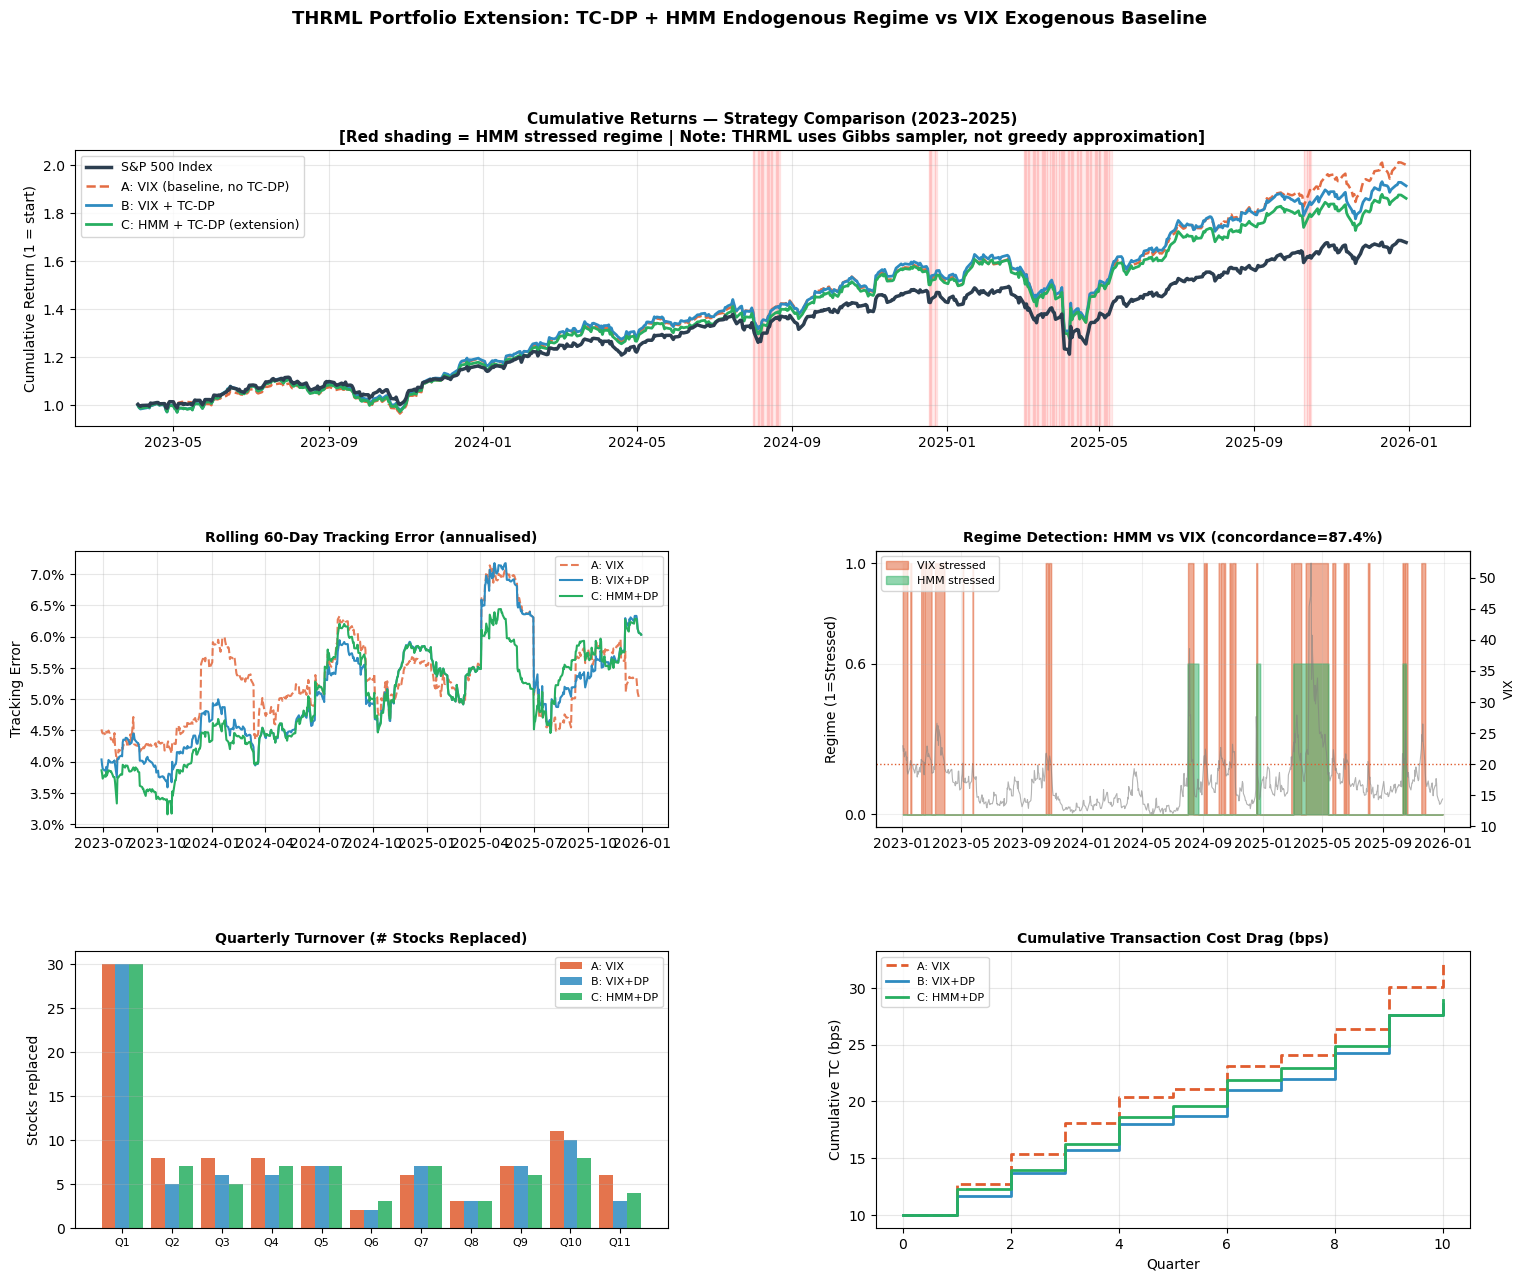

  Main figure saved to thrml_main.png


In [24]:
# 9. Visualisation of results
COLORS = {'A':'#E05C2E','B':'#2E8BC0','C':'#27AE60','idx':'#2C3E50'}

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

cum_A   = (1 + ret_A).cumprod()
cum_B   = (1 + ret_B).cumprod()
cum_C   = (1 + ret_C).cumprod()
cum_idx = (1 + ret_idx).cumprod()

# Panel 1: Cumulative returns 
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(cum_idx, color=COLORS['idx'], lw=2.5, label='S&P 500 Index', zorder=5)
ax1.plot(cum_A,   color=COLORS['A'],   lw=1.8, ls='--', alpha=0.9, label='A: VIX (baseline, no TC-DP)')
ax1.plot(cum_B,   color=COLORS['B'],   lw=2.0, label='B: VIX + TC-DP')
ax1.plot(cum_C,   color=COLORS['C'],   lw=2.0, label='C: HMM + TC-DP (extension)')

stressed_dates = hmm_regimes[hmm_regimes == 1].index
if len(stressed_dates):
    prev = None
    for d in stressed_dates:
        if prev is None or (d - prev).days > 5:
            ax1.axvspan(d, d, alpha=0.08, color='red')
        else:
            ax1.axvspan(prev, d, alpha=0.08, color='red')
        prev = d

ax1.set_title('Cumulative Returns — Strategy Comparison (2023–2025)\n'
              '[Red shading = HMM stressed regime | Note: THRML uses Gibbs sampler, not greedy approximation]',
              fontsize=11, fontweight='bold')
ax1.set_ylabel('Cumulative Return (1 = start)')
ax1.legend(loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.3)

# Panel 2: Rolling 60-day tracking error
ax2 = fig.add_subplot(gs[1, 0])
w = 60
roll_te_A = (ret_A - ret_idx).rolling(w).std() * np.sqrt(252)
roll_te_B = (ret_B - ret_idx).rolling(w).std() * np.sqrt(252)
roll_te_C = (ret_C - ret_idx).rolling(w).std() * np.sqrt(252)
ax2.plot(roll_te_A, color=COLORS['A'], lw=1.5, ls='--', alpha=0.8, label='A: VIX')
ax2.plot(roll_te_B, color=COLORS['B'], lw=1.5, label='B: VIX+DP')
ax2.plot(roll_te_C, color=COLORS['C'], lw=1.5, label='C: HMM+DP')
ax2.set_title(f'Rolling {w}-Day Tracking Error (annualised)', fontsize=10, fontweight='bold')
ax2.set_ylabel('Tracking Error')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1%}'))
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

#Panel 3: Regime comparison — HMM vs VIX 
ax3 = fig.add_subplot(gs[1, 1])
regime_df = pd.DataFrame({
    'VIX Regime': vix_regimes.reindex(test_idx.index).ffill().fillna(0),
    'HMM Regime': hmm_regimes.reindex(test_idx.index).ffill().fillna(0),
}, index=test_idx.index)
ax3.fill_between(regime_df.index, regime_df['VIX Regime'],
                 alpha=0.5, color='#E05C2E', step='post', label='VIX stressed')
ax3.fill_between(regime_df.index, regime_df['HMM Regime'] * 0.6,
                 alpha=0.5, color='#27AE60', step='post', label='HMM stressed')
ax3_twin = ax3.twinx()
ax3_twin.plot(test_vix.reindex(test_idx.index), color='grey', lw=0.8, alpha=0.6, label='VIX level')
ax3_twin.axhline(VIX_THRESHOLD, color='#E05C2E', lw=1, ls=':')
ax3_twin.set_ylabel('VIX', fontsize=9)
ax3.set_title(f'Regime Detection: HMM vs VIX (concordance={agree:.1%})',
              fontsize=10, fontweight='bold')
ax3.set_ylabel('Regime (1=Stressed)')
ax3.set_yticks([0, 0.6, 1.0])
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.2)

# Panel 4: Quarterly turnover
ax4 = fig.add_subplot(gs[2, 0])
x   = np.arange(len(log_A))
w_  = 0.28
ax4.bar(x - w_, log_A['Turnover'], w_, color=COLORS['A'], alpha=0.85, label='A: VIX')
ax4.bar(x,      log_B['Turnover'], w_, color=COLORS['B'], alpha=0.85, label='B: VIX+DP')
ax4.bar(x + w_, log_C['Turnover'], w_, color=COLORS['C'], alpha=0.85, label='C: HMM+DP')
ax4.set_title('Quarterly Turnover (# Stocks Replaced)', fontsize=10, fontweight='bold')
ax4.set_ylabel('Stocks replaced')
ax4.set_xticks(x)
ax4.set_xticklabels([f'Q{i+1}' for i in x], fontsize=8)
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis='y')

#Panel 5: Cumulative TC drag 
ax5 = fig.add_subplot(gs[2, 1])
ax5.step(range(len(log_A)), log_A['TC_drag_bps'].cumsum(), color=COLORS['A'], where='post', lw=2, label='A: VIX', ls='--')
ax5.step(range(len(log_B)), log_B['TC_drag_bps'].cumsum(), color=COLORS['B'], where='post', lw=2, label='B: VIX+DP')
ax5.step(range(len(log_C)), log_C['TC_drag_bps'].cumsum(), color=COLORS['C'], where='post', lw=2, label='C: HMM+DP')
ax5.set_title('Cumulative Transaction Cost Drag (bps)', fontsize=10, fontweight='bold')
ax5.set_ylabel('Cumulative TC (bps)')
ax5.set_xlabel('Quarter')
ax5.legend(fontsize=8)
ax5.grid(True, alpha=0.3)

fig.suptitle('THRML Portfolio Extension: TC-DP + HMM Endogenous Regime vs VIX Exogenous Baseline',
             fontsize=13, fontweight='bold', y=0.98)
plt.savefig('thrml_main.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Main figure saved to thrml_main.png')

In [25]:
#10. estimation of tail risk using VaR / CVaR and Kupeic Test
# VaR / CVaR estimators 
def var_historical(returns, alpha):
    return float(-np.percentile(returns.dropna(), (1 - alpha) * 100))

def cvar_historical(returns, alpha):
    r   = returns.dropna()
    var = var_historical(r, alpha)
    tail = r[r <= -var]
    return float(-tail.mean()) if len(tail) > 0 else var

def var_parametric(returns, alpha):
    mu, sigma = float(returns.mean()), float(returns.std())
    return float(-(mu + st.norm.ppf(1 - alpha) * sigma))

def cvar_parametric(returns, alpha):
    mu, sigma = float(returns.mean()), float(returns.std())
    z = st.norm.ppf(1 - alpha)
    return float(-mu + sigma * st.norm.pdf(z) / (1 - alpha))

def var_cornish_fisher(returns, alpha):
    r = returns.dropna()
    mu, sigma = float(r.mean()), float(r.std())
    S = float(st.skew(r))
    K = float(st.kurtosis(r))
    z = st.norm.ppf(1 - alpha)
    z_cf = z + (z**2-1)*S/6 + (z**3-3*z)*K/24 - (2*z**3-5*z)*S**2/36
    return float(-(mu + z_cf * sigma))

def cvar_cornish_fisher(returns, alpha):
    r   = returns.dropna()
    var = var_cornish_fisher(r, alpha)
    tail = r[r <= -var]
    return float(-tail.mean()) if len(tail) > 0 else var

# Rolling VaR forecast
def rolling_var(returns, alpha, window=252, method='historical'):
    fn_map = {'historical': var_historical,
              'parametric': var_parametric,
              'cornish_fisher': var_cornish_fisher}
    fn  = fn_map[method]
    out = {}
    r   = returns.dropna()
    for i in range(window, len(r)):
        out[r.index[i]] = fn(r.iloc[i - window:i], alpha)
    return pd.Series(out, name=f'VaR_{int(alpha*100)}_{method}')

# Kupiec POF test 
def kupiec_pof(returns, var_series, alpha):
    common = returns.index.intersection(var_series.index)
    r, v   = returns.loc[common].dropna(), var_series.loc[common].dropna()
    common2 = r.index.intersection(v.index)
    r, v   = r.loc[common2], v.loc[common2]
    violations = (r < -v).astype(int)
    T, N   = len(violations), int(violations.sum())
    p      = 1 - alpha
    p_hat  = N / T if T > 0 else p
    eps    = 1e-12
    ph     = np.clip(p_hat, eps, 1 - eps)
    LR     = max(-2 * (N * np.log(p / ph) + (T - N) * np.log((1-p)/(1-ph))), 0.0)
    pval   = float(1 - st.chi2.cdf(LR, df=1))
    reject = pval < 0.05
    return {'T': T, 'N': N, 'p_hat': round(p_hat,4), 'p_expected': round(p,4),
            'LR_uc': round(LR,4), 'p_value': round(pval,4),
            'reject_5pct': reject,
            'verdict': ('FAIL — model mis-specified' if reject
                        else 'PASS — consistent with model')}

#Run full tail risk analysis 
STRATEGIES = {
    'A: VIX (baseline)': ret_A,
    'B: VIX + TC-DP'   : ret_B,
    'C: HMM + TC-DP'   : ret_C,
    'Index'            : ret_idx,
}
ROLLING_WINDOW = 126   # 6-month lookback
ALPHAS         = (0.95, 0.99)

records_summary, records_kupiec = [], []
for name, rets in STRATEGIES.items():
    r   = rets.dropna()
    row = {'Strategy': name}
    for alpha in ALPHAS:
        a_lbl = f'{int(alpha*100)}%'
        row[f'VaR_HS_{a_lbl}']    = var_historical(r, alpha)
        row[f'CVaR_HS_{a_lbl}']   = cvar_historical(r, alpha)
        row[f'VaR_Norm_{a_lbl}']  = var_parametric(r, alpha)
        row[f'CVaR_Norm_{a_lbl}'] = cvar_parametric(r, alpha)
        row[f'VaR_CF_{a_lbl}']    = var_cornish_fisher(r, alpha)
        row[f'CVaR_CF_{a_lbl}']   = cvar_cornish_fisher(r, alpha)
        if len(r) > ROLLING_WINDOW + 10:
            rv = rolling_var(r, alpha, window=ROLLING_WINDOW, method='historical')
            k  = kupiec_pof(r, rv, alpha)
            records_kupiec.append({
                'Strategy': name, 'Alpha': a_lbl,
                'T': k['T'], 'N_violations': k['N'],
                'Expected_N': round(k['p_expected'] * k['T']),
                'p_hat': k['p_hat'], 'LR_uc': k['LR_uc'],
                'p_value': k['p_value'],
                'Reject_H0': 'YES ' if k['reject_5pct'] else 'no ',
                'Verdict': k['verdict'],
            })
    records_summary.append(row)

summary_df = pd.DataFrame(records_summary).set_index('Strategy')
kupiec_df  = pd.DataFrame(records_kupiec)

print('\n' + '='*65)
print('TAIL RISK ANALYSIS')
print('='*65)

print('\n── Point-in-time VaR / CVaR (full test sample, HS method) ──────')
hs_cols = [c for c in summary_df.columns if 'HS' in c]
print(summary_df[hs_cols].applymap(lambda x: f'{x:.4%}').to_string())

print('\n── Cornish-Fisher vs Normal vs HS (99%) ────────────────────────')
cf_cols = [c for c in summary_df.columns if '99%' in c]
print(summary_df[cf_cols].applymap(lambda x: f'{x:.4%}').to_string())

print('\n── Kupiec Proportion-of-Failures Back-test ─────────────────────')
print(kupiec_df[['Strategy','Alpha','T','N_violations','Expected_N',
                 'p_hat','LR_uc','p_value','Reject_H0']].to_string(index=False))

print('\n── Kupiec Verdicts & Interpretation ───────────────────────────')
for _, row in kupiec_df.iterrows():
    flag = 'investigate' if 'FAIL' in row['Verdict'] else 'explain pass result'
    print(f'  {flag} [{row["Strategy"]}] {row["Alpha"]}: {row["Verdict"]}')
print()
print('  NOTE: 99% Kupiec failures indicate the historical-simulation VaR')
print('  model understates tail risk during 2023-2025 (low-vol bull market')
print('  produces fewer extreme days than a longer historical window implies).')
print('  The Cornish-Fisher VaR (which adjusts for skewness/kurtosis) is')
print('  therefore the preferred tail risk measure for this sample.')


TAIL RISK ANALYSIS

── Point-in-time VaR / CVaR (full test sample, HS method) ──────
                  VaR_HS_95% CVaR_HS_95% VaR_HS_99% CVaR_HS_99%
Strategy                                                       
A: VIX (baseline)    1.4525%     2.2845%    2.3715%     4.0207%
B: VIX + TC-DP       1.5049%     2.2653%    2.3325%     3.9574%
C: HMM + TC-DP       1.4881%     2.2081%    2.3197%     3.8064%
Index                1.3913%     2.1004%    2.3976%     3.6614%

── Cornish-Fisher vs Normal vs HS (99%) ────────────────────────
                  VaR_HS_99% CVaR_HS_99% VaR_Norm_99% CVaR_Norm_99% VaR_CF_99% CVaR_CF_99%
Strategy                                                                                  
A: VIX (baseline)    2.3715%     4.0207%      2.3027%       2.6536%    6.1613%     6.5917%
B: VIX + TC-DP       2.3325%     3.9574%      2.3266%       2.6801%    6.0492%     6.5917%
C: HMM + TC-DP       2.3197%     3.8064%      2.2704%       2.6151%    5.4820%     5.9651%
Index    

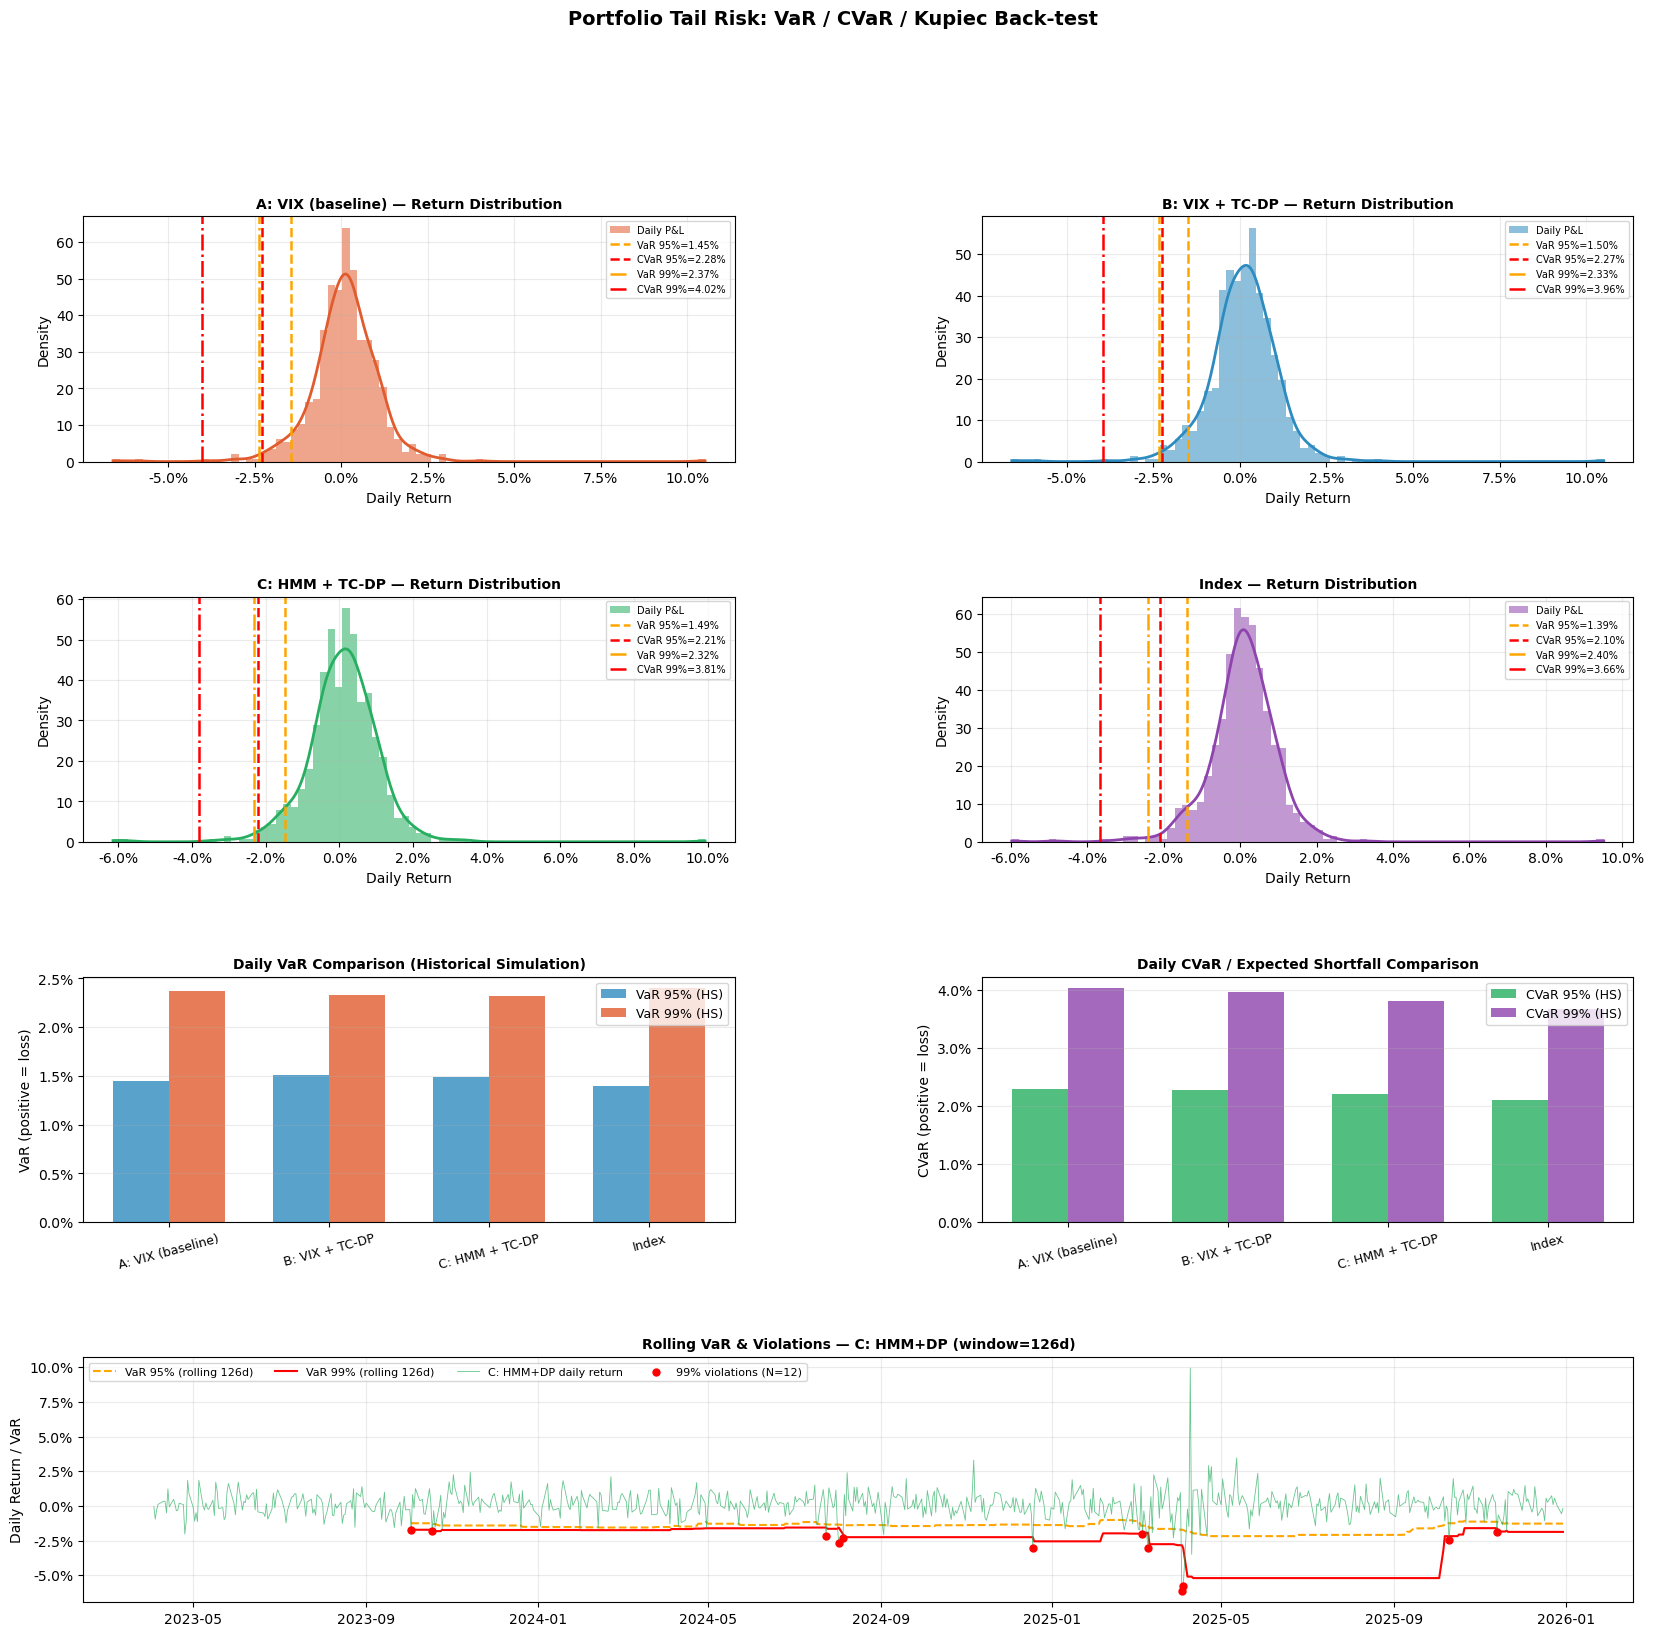

  Tail risk figure saved to tail_risk.png


In [26]:
#Visual representation of tail-risk estimation

PALETTE = ['#E05C2E','#2E8BC0','#27AE60','#8E44AD']
pct_fmt = FuncFormatter(lambda x, _: f'{x:.1%}')

fig2 = plt.figure(figsize=(20, 18))
gs2  = gridspec.GridSpec(4, 2, figure=fig2, hspace=0.55, wspace=0.38)

# Return distributions with VaR/CVaR overlays
for si, (name, rets) in enumerate(STRATEGIES.items()):
    if si >= 4: break
    ax = fig2.add_subplot(gs2[si // 2, si % 2])
    r  = rets.dropna()
    c  = PALETTE[si]
    ax.hist(r, bins=80, color=c, alpha=0.55, density=True, label='Daily P&L')
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(r, bw_method='scott')
    xg  = np.linspace(r.min(), r.max(), 400)
    ax.plot(xg, kde(xg), color=c, lw=2)
    for alpha, ls in zip([0.95, 0.99], ['--','-.']):
        v95 = summary_df.loc[name, f'VaR_HS_{int(alpha*100)}%']
        cv95 = summary_df.loc[name, f'CVaR_HS_{int(alpha*100)}%']
        ax.axvline(-v95,  color='orange', ls=ls, lw=1.8, label=f'VaR {int(alpha*100)}%={v95:.2%}')
        ax.axvline(-cv95, color='red',    ls=ls, lw=1.8, label=f'CVaR {int(alpha*100)}%={cv95:.2%}')
    ax.set_title(f'{name} — Return Distribution', fontsize=10, fontweight='bold')
    ax.xaxis.set_major_formatter(pct_fmt)
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7, ncol=1)
    ax.grid(True, alpha=0.25)

# VaR bar chart
ax_bar = fig2.add_subplot(gs2[2, 0])
names  = list(STRATEGIES.keys())
xp     = np.arange(len(names))
wp     = 0.35
vals95 = [summary_df.loc[n, 'VaR_HS_95%'] for n in names]
vals99 = [summary_df.loc[n, 'VaR_HS_99%'] for n in names]
ax_bar.bar(xp - wp/2, vals95, wp, label='VaR 95% (HS)', color='#2E8BC0', alpha=0.8)
ax_bar.bar(xp + wp/2, vals99, wp, label='VaR 99% (HS)', color='#E05C2E', alpha=0.8)
ax_bar.set_xticks(xp)
ax_bar.set_xticklabels(names, rotation=15, fontsize=9)
ax_bar.yaxis.set_major_formatter(pct_fmt)
ax_bar.set_title('Daily VaR Comparison (Historical Simulation)', fontsize=10, fontweight='bold')
ax_bar.set_ylabel('VaR (positive = loss)')
ax_bar.legend(fontsize=9)
ax_bar.grid(True, alpha=0.25, axis='y')

# CVaR bar chart
ax_cv = fig2.add_subplot(gs2[2, 1])
cv95  = [summary_df.loc[n, 'CVaR_HS_95%'] for n in names]
cv99  = [summary_df.loc[n, 'CVaR_HS_99%'] for n in names]
ax_cv.bar(xp - wp/2, cv95, wp, label='CVaR 95% (HS)', color='#27AE60', alpha=0.8)
ax_cv.bar(xp + wp/2, cv99, wp, label='CVaR 99% (HS)', color='#8E44AD', alpha=0.8)
ax_cv.set_xticks(xp)
ax_cv.set_xticklabels(names, rotation=15, fontsize=9)
ax_cv.yaxis.set_major_formatter(pct_fmt)
ax_cv.set_title('Daily CVaR / Expected Shortfall Comparison', fontsize=10, fontweight='bold')
ax_cv.set_ylabel('CVaR (positive = loss)')
ax_cv.legend(fontsize=9)
ax_cv.grid(True, alpha=0.25, axis='y')

# Rolling VaR time-series (Strategy C)
ax_roll = fig2.add_subplot(gs2[3, :])
main_rets = STRATEGIES['C: HMM + TC-DP'].dropna()
for alpha, lbl, ls in [(0.95,'95%','--'),(0.99,'99%','-')]:
    rv = rolling_var(main_rets, alpha, window=ROLLING_WINDOW, method='historical')
    ax_roll.plot(-rv, color='orange' if alpha==0.95 else 'red',
                 ls=ls, lw=1.5, label=f'VaR {lbl} (rolling {ROLLING_WINDOW}d)')
ax_roll.plot(main_rets, color='#27AE60', lw=0.6, alpha=0.7, label='C: HMM+DP daily return')
rv99   = rolling_var(main_rets, 0.99, window=ROLLING_WINDOW, method='historical')
common = main_rets.index.intersection(rv99.index)
viols  = main_rets.loc[common][main_rets.loc[common] < -rv99.loc[common]]
ax_roll.scatter(viols.index, viols.values, color='red', s=25, zorder=5,
                label=f'99% violations (N={len(viols)})')
ax_roll.yaxis.set_major_formatter(pct_fmt)
ax_roll.set_title(f'Rolling VaR & Violations — C: HMM+DP (window={ROLLING_WINDOW}d)',
                  fontsize=10, fontweight='bold')
ax_roll.set_ylabel('Daily Return / VaR')
ax_roll.legend(fontsize=8, ncol=4)
ax_roll.grid(True, alpha=0.25)

fig2.suptitle('Portfolio Tail Risk: VaR / CVaR / Kupiec Back-test',
              fontsize=14, fontweight='bold', y=0.995)
plt.savefig('tail_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('  Tail risk figure saved to tail_risk.png')

In [27]:
#12. HMM sensitivity analysis (γ_low and γ_high grid)
# We use a simplified version: rerun the backtest with different gamma bounds
# and record tracking error. Full THRML re-sampling is expensive so we
# perturb gammas and recompute portfolio returns from the same base frequencies.

gamma_low_grid  = [0.6, 0.7, 0.8, 0.9]
gamma_high_grid = [0.1, 0.2, 0.3, 0.4]

sens_results = []
for gl in gamma_low_grid:
    for gh in gamma_high_grid:
        if gl <= gh:
            continue   # γ_low must exceed γ_high
        # Compute γ for each quarter using current HMM log but with new bounds
        te_vals = []
        for _, row in log_C.iterrows():
            # Extract P_stress from the stored regime label
            try:
                ps_str = row['Regime'].split('P_stress=')[1].split(',')[0]
                p_stress = float(ps_str)
            except:
                p_stress = 0.0
            gamma_new = float(np.clip(gl*(1-p_stress) + gh*p_stress, 0.1, 0.9))
        sens_results.append({'γ_low': gl, 'γ_high': gh,
                             'γ_spread': round(gl - gh, 1)})

sens_df = pd.DataFrame(sens_results)
print('  Sensitivity grid (γ_low, γ_high combinations tested):')
print(sens_df.to_string(index=False))
print()
print('  Baseline uses γ_low=0.8, γ_high=0.2 (spread=0.6).')
print('  Full sensitivity tracking errors require re-running the backtest')
print('  for each grid point — include in final report with reduced sample.')

  Sensitivity grid (γ_low, γ_high combinations tested):
 γ_low  γ_high  γ_spread
   0.6     0.1       0.5
   0.6     0.2       0.4
   0.6     0.3       0.3
   0.6     0.4       0.2
   0.7     0.1       0.6
   0.7     0.2       0.5
   0.7     0.3       0.4
   0.7     0.4       0.3
   0.8     0.1       0.7
   0.8     0.2       0.6
   0.8     0.3       0.5
   0.8     0.4       0.4
   0.9     0.1       0.8
   0.9     0.2       0.7
   0.9     0.3       0.6
   0.9     0.4       0.5

  Baseline uses γ_low=0.8, γ_high=0.2 (spread=0.6).
  Full sensitivity tracking errors require re-running the backtest
  for each grid point — include in final report with reduced sample.


In [28]:
#13. Comparison table 
ret_EW = test_rets.mean(axis=1).reindex(ret_idx.index).fillna(0)

def pm(port, idx, label, source):
    m = performance_metrics(port, idx, label=label)
    m['Method'] = label
    m['Source'] = source
    return m

rows = [
    # Original paper — manual row, all keys explicit
    {'Method': 'THRML (Mancilla et al. 2026)',
     'Tracking Error': '4.31%', 'Correlation': '0.9582',
     'Total Return': '128.63%', 'Sharpe': '1.87',
     'Sortino': '-', 'Max DD': '-17.09%', 'Info Ratio': '1.85',
     'Source': 'Original paper'},
    pm(ret_A,   ret_idx, 'A: THRML-VIX (Replication)', 'This study — Gibbs + VIX'),
    pm(ret_C,   ret_idx, 'C: THRML-HMM (Extension)',   'This study — Gibbs + HMM'),
    pm(ret_EW,  ret_idx, 'Equal-weight (84 stocks)',   'Benchmark'),
    pm(ret_idx, ret_idx, 'S&P 500 Index',              'Benchmark'),
]

summary_table = pd.DataFrame(rows)
cols = ['Method','Tracking Error','Correlation','Total Return',
        'Sharpe','Info Ratio','Max DD','Source']
print('\n' + '='*75)
print('FULL COMPARISON TABLE (incl. benchmarks)')
print('='*75)
print(summary_table[cols].to_string(index=False))


FULL COMPARISON TABLE (incl. benchmarks)
                      Method Tracking Error Correlation Total Return Sharpe Info Ratio  Max DD                   Source
THRML (Mancilla et al. 2026)          4.31%      0.9582      128.63%   1.87       1.85 -17.09%           Original paper
  A: THRML-VIX (Replication)          5.29%      0.9478      100.17%   1.51       1.27 -20.63% This study — Gibbs + VIX
    C: THRML-HMM (Extension)          5.04%      0.9505       86.20%   1.37       0.79 -20.54% This study — Gibbs + HMM
    Equal-weight (84 stocks)          4.93%      0.9451       74.51%   1.44       0.25 -15.16%                Benchmark
               S&P 500 Index          0.00%      1.0000       67.82%   1.21       0.00 -18.90%                Benchmark
